
# Demo of DBSCAN clustering algorithm

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds core
samples in regions of high density and expands clusters from them. This
algorithm is good for data which contains clusters of similar density.

See the `sphx_glr_auto_examples_cluster_plot_cluster_comparison.py` example
for a demo of different clustering algorithms on 2D datasets.


In [4]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# ESte ejemplo está tomado de la documentación oficial de sklearn (https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html)

In [1]:
%pip install scikit-learn scipy numpy pandas matplotlib seaborn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 44.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/36.5 MB 23.9 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/36.5 MB 38.2 MB/s eta 0:00:01
   --------------------------------- ------ 30.1/36.5 MB 47.7 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 44.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 12.3/12.3 MB 63.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.7 MB ? e


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data generation

We use :class:`~sklearn.datasets.make_blobs` to create 3 synthetic clusters.



In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

We can visualize the resulting data:



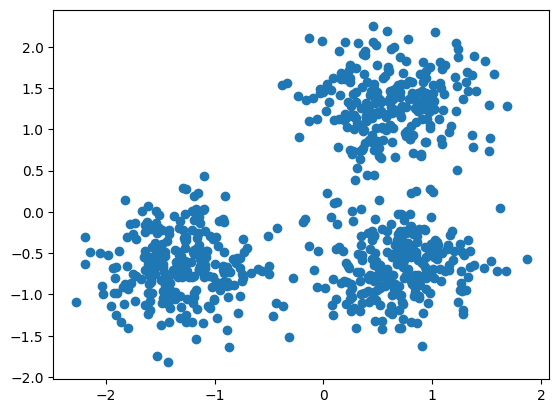

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

## Compute DBSCAN

One can access the labels assigned by :class:`~sklearn.cluster.DBSCAN` using
the `labels_` attribute. Noisy samples are given the label $-1$.



In [7]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


Clustering algorithms are fundamentally unsupervised learning methods.
However, since :class:`~sklearn.datasets.make_blobs` gives access to the true
labels of the synthetic clusters, it is possible to use evaluation metrics
that leverage this "supervised" ground truth information to quantify the
quality of the resulting clusters. Examples of such metrics are the
homogeneity, completeness, V-measure, Rand-Index, Adjusted Rand-Index and
Adjusted Mutual Information (AMI).

If the ground truth labels are not known, evaluation can only be performed
using the model results itself. In that case, the Silhouette Coefficient comes
in handy.

For more information, see the
`sphx_glr_auto_examples_cluster_plot_adjusted_for_chance_measures.py`
example or the `clustering_evaluation` module.



In [4]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


## Plot results

Core samples (large dots) and non-core samples (small dots) are color-coded
according to the assigned cluster. Samples tagged as noise are represented in
black.



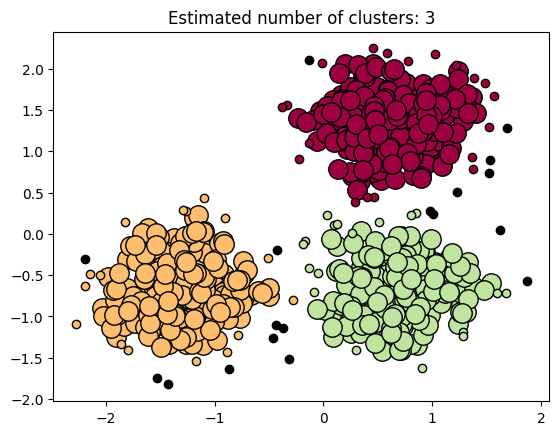

In [5]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## VAmos a ver ahora el resultado de aplicar K-Means

In [3]:
from sklearn.cluster import KMeans

# Definimos K-Means. Usamos 3 porque sabemos que el notebook generó 3 centros.
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X)

## visualización

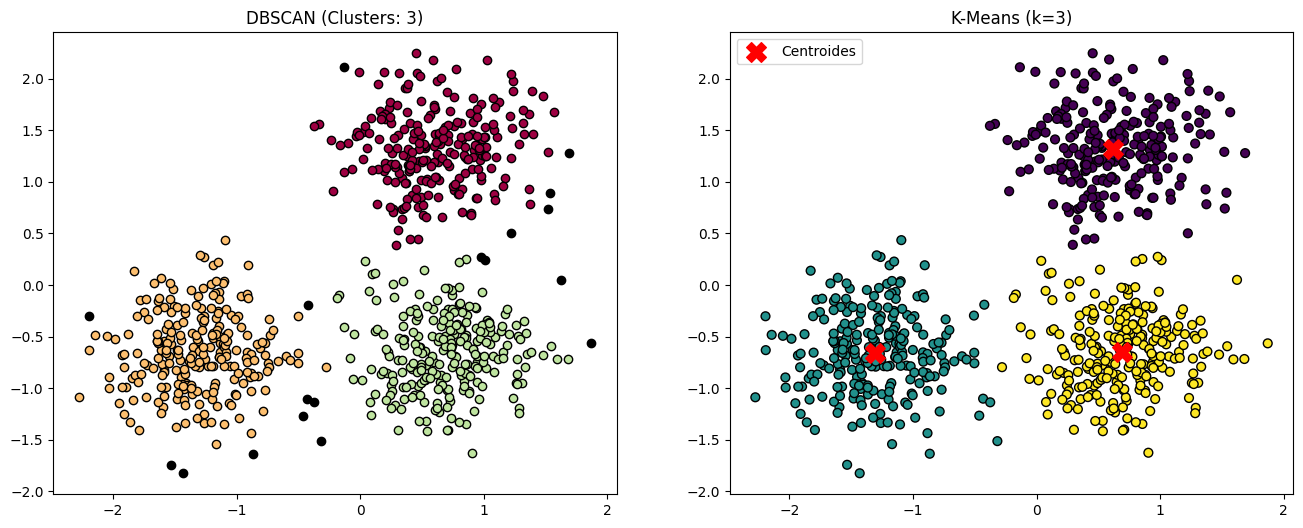

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Verificamos si 'labels' existe, si no, damos un mensaje de error claro
if 'labels' not in locals():
    print("Error: La variable 'labels' no existe. Ejecuta la celda de DBSCAN primero.")
else:
    # Definimos las etiquetas únicas para el gráfico
    unique_labels = set(labels)
    n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)

    # Crear el lienzo
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- PANEL 1: DBSCAN ---
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1: col = [0, 0, 0, 1]  # Negro para el ruido
        class_member_mask = (labels == k)
        ax1.plot(X[class_member_mask, 0], X[class_member_mask, 1], 'o', 
                 markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
    ax1.set_title(f'DBSCAN (Clusters: {n_clusters_})')

    # --- PANEL 2: K-MEANS ---
    ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=40, edgecolors='k')
    centers_km = kmeans.cluster_centers_
    ax2.scatter(centers_km[:, 0], centers_km[:, 1], s=200, marker='X', c='red', label='Centroides')
    ax2.set_title('K-Means (k=3)')
    ax2.legend()

    plt.show()